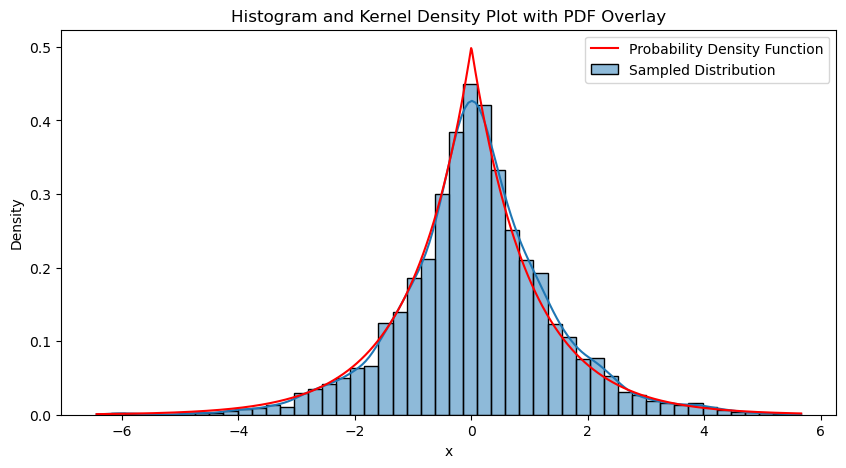

Sample Mean: 0.07914833001526135
Sample Standard Deviation: 1.315989281687335


In [4]:
## 1(a)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define the target distribution (Laplace PDF, ignoring constant factor)
def f(x):
    return np.exp(-abs(x))

# Metropolis-Hastings Algorithm
np.random.seed(42)  # For reproducibility
N = 10000  # Number of samples
s = 1  # Standard deviation of proposal distribution

x = np.zeros(N)
x[0] = 0  # Initial value

for i in range(1, N):
    x_proposed = np.random.normal(x[i-1], s)  # Proposal step
    acceptance_ratio = f(x_proposed) / f(x[i-1])
    
    if np.random.uniform(0, 1) < acceptance_ratio:
        x[i] = x_proposed
    else:
        x[i] = x[i-1]

# Plot histogram and KDE of samples
plt.figure(figsize=(10, 5))
sns.histplot(x, bins=50, kde=True, stat="density", label="Sampled Distribution")

# Overlay true Laplace distribution for comparison
x_vals = np.linspace(min(x), max(x), 1000)
plt.plot(x_vals, 0.5 * np.exp(-abs(x_vals)), label="Probability Density Function", color='red')

plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.title("Histogram and Kernel Density Plot with PDF Overlay")
plt.show()

# Report sample mean and standard deviation
sample_mean = np.mean(x)
sample_std = np.std(x)
print(f"Sample Mean: {sample_mean}")
print(f"Sample Standard Deviation: {sample_std}")

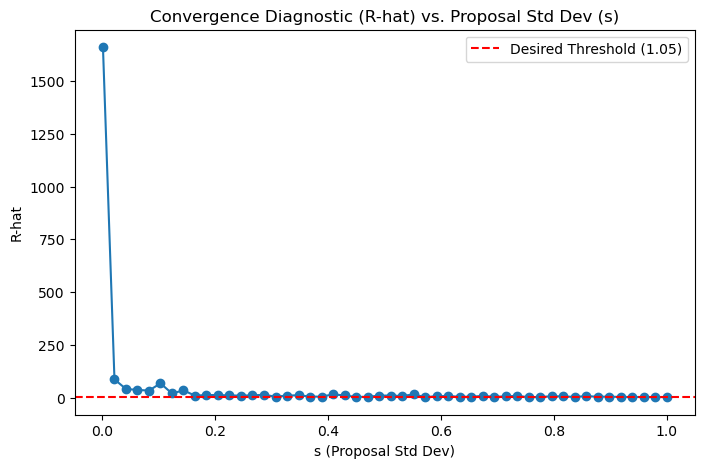

Final R-hat value for s=1.000: 2.384
R-hat value for s=0.001: 1661.264


In [14]:
## 1(b)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define the target distribution (PDF, ignoring constant factor)
def f(x):
    return np.exp(-abs(x))

# Metropolis-Hastings Algorithm
def metropolis_hastings(N, s, x0):
    x = np.zeros(N)
    x[0] = x0
    
    for i in range(1, N):
        x_proposed = np.random.normal(x[i-1], s)  # Proposal step
        acceptance_ratio = f(x_proposed) / f(x[i-1])
        
        if np.random.uniform(0, 1) < acceptance_ratio:
            x[i] = x_proposed
        else:
            x[i] = x[i-1]
    
    return x

# Parameters
N = 2000  # Number of samples per chain
J = 4  # Number of chains
s_values = np.linspace(0.001, 1, 50)  # Grid of s values

# Compute R-hat values for different s
R_hat_values = []
R_hat_for_s_001 = None
for s in s_values:
    chains = [metropolis_hastings(N, s, np.random.randn()) for _ in range(J)]
    
    # Compute M_j (mean of each chain)
    M_j = np.mean(chains, axis=1)
    
    # Compute V_j (within variance of each chain)
    V_j = np.var(chains, axis=1, ddof=1)
    
    # Compute W (overall within-chain variance)
    W = np.mean(V_j)
    
    # Compute overall sample mean M
    M = np.mean(M_j)
    
    # Compute B (between-chain variance)
    B = (N / (J - 1)) * np.sum((M_j - M) ** 2)
    
    # Compute R-hat
    R_hat = np.sqrt((B + W) / W)
    R_hat_values.append(R_hat)
    
    # Store R-hat for s = 0.001
    if np.isclose(s, 0.001, atol=1e-6):
        R_hat_for_s_001 = R_hat

# Plot R-hat values
plt.figure(figsize=(8, 5))
plt.plot(s_values, R_hat_values, marker='o', linestyle='-')
plt.axhline(y=1.05, color='r', linestyle='--', label='Desired Threshold (1.05)')
plt.xlabel("s (Proposal Std Dev)")
plt.ylabel("R-hat")
plt.title("Convergence Diagnostic (R-hat) vs. Proposal Std Dev (s)")
plt.legend()
plt.show()

# Report final R-hat value for the last s
print(f"Final R-hat value for s={s_values[-1]:.3f}: {R_hat_values[-1]:.3f}")
# Report R-hat for s = 0.001
print(f"R-hat value for s=0.001: {R_hat_for_s_001:.3f}")
